# Neural Networks

Neural Networks (NN) is a Machine Learning algorithm that takes a big step in trying to mimic how the human brain functions. They are the foundation of a lot of major breakthroughs in Machine Learning, whether that be image or speech recognition, or LLMs! On first instinct, NNs seem like an intimidating concept to understand.

However, once we break it down into it's fundamental parts, as I'll do in this notebook, we realise that a Neural Network is just a series of regression models built on top of each other. 

### What does a NN look like?

As seen in the diagram below, Neural Network is comprised of 3 parts:

1) An input layer (i.e. your dataset, X) *(in pink)*
2) Hidden layer(s) *(in yellow)*
3) An output layer *(in blue)*

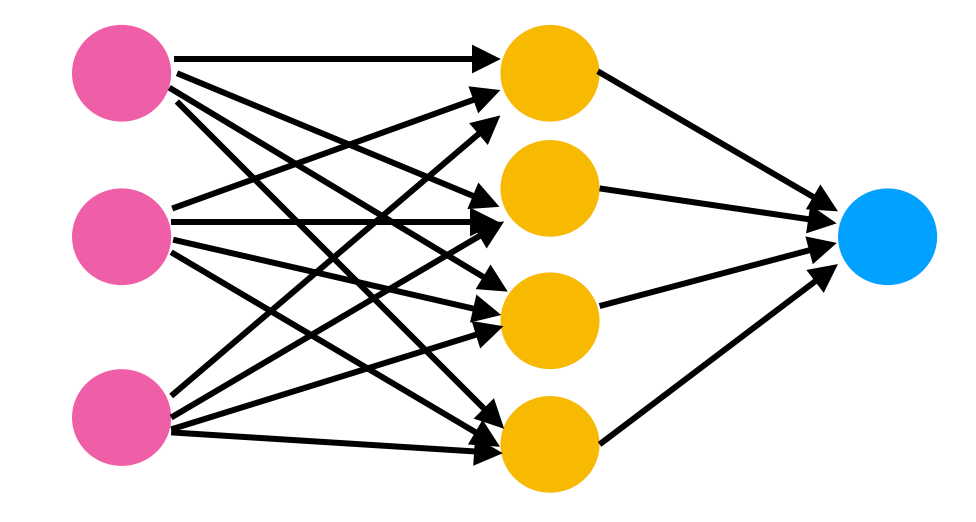

This image illustrates one possible Neural Network model structure out of infinite possibilities. We have the ability to specify...

- How many hidden layers there are
- The size of the hidden or output layers (i.e. how many circles, also called *'neurons'* or *'units'*)

Note that we don't *really* have the ability to specify the size of the input layer - this is predetermined by the size of the dataset we have been given.

### What does each neuron do?

Each neuron in the hidden and output layer has an activation function which takes into account the input from the previous layer, and spits out some number $z$. In many ways, it can be seen as performing it's own regression on the given input. 

What kind of regression, you may ask? The 2 most commonly used are "ReLU" and "Logistic" (*referred to as Sigmoid*).

If you've read my previous notes on Logistic regression, you should hopefully be familiar with how the **Sigmoid** function works:

$$
g(\mathbf{x}^{(i)}) = \frac{1}{1+e^{\mathbf{w} \cdot \mathbf{x}^{(i)} + b }}
$$

The ReLU function *(short-form for Rectified Linear Unit)* takes the form:

$$
g(\mathbf{x}^{(i)}) = \max(0, \mathbf{w} \cdot \mathbf{x}^{(i)} + b )
$$

So, in our diagram above, our **yellow hidden layer** takes the data (circles) from the **pink input layer** and applies either a Sigmoid or ReLU function to it. Each neuron in the **hidden layer**, given its own weights $w$ and bias $b$, then spits out a number $g(\mathbf{x}^{(i)})$. 

In the final output layer, the neuron then collects $g(\mathbf{x}^{(i)})$ for each of the 4 neurons and applies its own function to it, spitting out a final prediction.

This process is called **forward propagation**. 

Let's start building this NN by generating functions that allow us, for a layer, to specify how many neurons there are, their activation function and the process of forward propagation.

---

Step 1: **Generate** structure of hidden and output layers

In [ ]:
class Layer:
    def __init__(self, input_dim, output_dim, activation = None):
        self.W = np.random.randn(input_dim, output_dim)
        self.b = np.random.randn(1, output_dim)
        self.activation = activation
        self.input = None
        self.Z = None
        self.output = None

    def apply_activation(self,Z):
        if self.activation == "relu":
            return np.maximum(0,Z)
        elif self.activation == "sigmoid":
            return 1 / (1 + np.exp(-Z))
        elif self.activation == None or self.activation == "linear":
            return Z
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

    def forward(self, X):
        self.input = X
        self.Z = np.dot(X, self.W) + self.b
        self.output = self.apply_activation(self.Z)
        return self.output
        
        

The above code allows us to build a singular layer in our neural network. We can specify:
- the number of neurons in the preceding layer, ```input_dim```, which determines the number of rows of our weight ```W```
- the size of the layer itself, ```output_dim```, which determines the number of columns of our weight ```W```
- the ```activation``` function which determines how the neurons transform the input

The ```forward``` function, with the help of ```apply_activation```performs this transformation. We can test this with the following code:

```
layer = Layer(input_dim = 3, output_dim = 4, activation = "relu")
X = np.array([1.0,2.0,3.0])
layer.forward(X)
```


Now that we've built the layer, we want to develop a function that enables us to stack these layers on top of each other, as in a network!

---

Step 2: Build a class function that takes the output from one layer as the input for the next layer.

In [ ]:
def Sequential:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

We can test this function using the following code:

```
X = np.array([[1.0,2.0,3.0]])

model = Sequential([Layer(input_dim = 3, output_dim = 4, activation = "relu"), #Hidden layer in our model picture above
                    Layer(input_dim = 4, output_dim = 1, activation = "sigmoid")]) #Output layer

output = model.forward(X)
print(output)
```

We now want to find a way to refine the values of $W$ and $b$ to generate more accurate predictions. In linear and logistic regression, this process was called Gradient Descent. For NN, the process is **backwards propagation**

#### How does backwards propagation work?

Once our model has made its first prediction, we can compute the loss i.e. difference between $\hat{y}$ and $y$. Assuming our output layer's activation function is sigmoid, the loss is:

$$
loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
$$

You may recognise this as the identical loss function for logistic regression. 

Our cost function is then a sum of the loss for all examples.

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

Note however, that $J$ is not just a function of $(\mathbf{w},b)$ in the output layer, but a function of all $w$ and all $b$ in each layer! This is because the predicted output $\hat{y}$ is generated from the output layer *and* all the hidden layers before it.

In each layer, we want to understand how the final output cost $J$ is affected by small changes in that layer's $w$ and $b$. 

Let's break down what happens in each layer *(from our model in the diagram above)* starting from the output layer. To simplify this, let's start with just one example.

#### 1. Output layer

Let's assume our output layer has a **sigmoid** activation function. Given 

We have computed a cost: 

$$
J = \mathcal{L} = -y \log\left( \hat{y} \right) - (1 - y) \log\left( 1 - \hat{y} \right)
$$

Note that $\hat{y}$ is the representation of our activation function's output, $a^{[L]}$. I've included a superscript $[L]$ to highlight that this is the activation output of the output layer, $[L]$.

$$
\hat{y} = a^{[L]} = \sigma(z^{[L]}) = \sigma(w^{[L]} a^{[L-1]} + b^{[L]}) = \frac{1}{1 + e^{-z^{[L]}}}
$$

So, 

$$
J = \mathcal{L} = -y \log\left( a^{[L]} \right) - (1 - y) \log\left( 1 - a^{[L]} \right)
$$

We want to calculate how $J$ changes with $w$ and $b$. 

Using chain rule, we can calculate this as:

$$
\frac{dJ}{dw^{[L]}} = \frac{dJ}{da^{[L]}} \cdot \frac{da^{[L]}}{dz^{[L]}} \cdot \frac{dz^{[L]}}{dw^{[L]}}
$$

and

$$
\frac{dJ}{db^{[L]}} = \frac{dJ}{da^{[L]}} \cdot \frac{da^{[L]}}{dz^{[L]}} \cdot \frac{dz^{[L]}}{db^{[L]}}
$$

So, there are 4 main derivates that we need to backsolve for:

$$
\frac{dJ}{da^{[L]}}, \frac{da^{[L]}}{dz^{[L]}}, \frac{dz^{[L]}}{dw^{[L]}},  \frac{dz^{[L]}}{db^{[L]}}
$$


We can first identify how cost $J$ changes with $a$: 
$$
\frac{dJ}{da^{[L]}} = -\frac{y}{a^{[L]}} + \frac{1 - y}{1 - a^{[L]}}
$$

Next, we can identify how $a^{[L]}$ changes with $z^{[L]}$:

$$
\frac{da^{[L]}}{dz^{[L]}} = \frac{d}{dz^{[L]}} \left( \frac{1}{1 + e^{-z^{[L]}}} \right) = a^{[L]}(1 - a^{[L]})
$$

Finally, we can calculate $\frac{dz^{[L]}}{dw^{[L]}}$ and $\frac{dz^{[L]}}{db^{[L]}}$.

Remember that: 

$$
z^{[L]} = \mathbf{w^{[L]}} \cdot \mathbf{a^{[L-1]}} + b^{[L]}
$$

So...

$$
\frac{dz^{[L]}}{dw^{[L]}} = \mathbf{a^{[L-1]}}, \frac{dz^{[L]}}{db^{[L]}} = 1
$$

Using chain-rule, we can now understand what $\frac{dJ}{d\mathbf{w}^{[L]}}$ and $\frac{dJ}{db^{[L]}}$ are.

Our next step will be to calculate how $J$ changes relative to weights and biases in the hidden layer, $[L-1]$:

$$\frac{dJ}{d\mathbf{w}^{[L-1]}}$$ and $$\frac{dJ}{db^{[L-1]}}$$

To help with this, whilst still in the output layer, we can calculate an additional derivative:

$$
\frac{dJ}{d\mathbf{a}^{[L-1]}} = \frac{dJ}{d\mathbf{z}^{[L]}} \cdot \frac{d\mathbf{z}^{[L]}}{d\mathbf{a}^{[L-1]}}
= \left( \frac{dJ}{d\mathbf{z}^{[L]}} \right) \cdot \left( \mathbf{w}^{[L]} \right)^\top
$$

Where

$$
\frac{dJ}{d\mathbf{z}^{[L]}} = \frac{dJ}{d\mathbf{a}^{[L]}} \cdot \frac{d\mathbf{a}^{[L]}}{d\mathbf{z}^{[L]}}
$$

---


#### 2. Hidden Layer $L - 1$

Now that we've computed $\frac{dJ}{d\mathbf{w}^{[L]}}$ and $\frac{dJ}{d\mathbf{b}^{[L]}}$ for the output layer, we want to move one step backwards in the network and calculate the gradients for the previous (hidden) layer

$$\frac{dJ}{d\mathbf{w}^{[L-1]}}$$ and $$\frac{dJ}{db^{[L-1]}}$$

To do this, we use the **chain rule** again. In particular, we willl need the derivatives...

$$
\frac{dJ}{da^{[L-1]}}, \frac{da^{[L-1]}}{dz^{[L-1]}}, \frac{dz^{[L-1]}}{dw^{[L-1]}},  \frac{dz^{[L-1]}}{db^{[L-1]}}
$$

Note that we now care about how the cost $J$ changes with respect to $\mathbf{z}^{[L-1]}$ - **the pre-activation output of the hidden layer**.

$$
\frac{dJ}{d\mathbf{z}^{[L-1]}} = \frac{dJ}{d\mathbf{a}^{[L-1]}} \cdot \frac{d\mathbf{a}^{[L-1]}}{d\mathbf{z}^{[L-1]}}
$$

We calculated $\frac{dJ}{d\mathbf{a}^{[L-1]}}$ in the output layer. 

$\frac{d\mathbf{a}^{[L-1]}}{d\mathbf{z}^{[L-1]}}$ depends on the activation function that we are using in our hidden layer.

a) If our activation function is **ReLu**:

$$
\mathbf{a}^{[L-1]} = \mathbf{a}^{[L-1]} = \text{ReLU}(\mathbf{z}^{[L-1]}) = \max(0, \mathbf{z}^{[L-1]})
$$

$$
\frac{d\mathbf{a}^{[L-1]}}{d\mathbf{z}^{[L-1]}} =
\begin{cases}
1 & \text{if } \mathbf{z}^{[L-1]} > 0 \\
0 & \text{otherwise}
\end{cases}
$$

b) If our activation function is **Sigmoid**:

$$
\mathbf{a}^{[L-1]} = \sigma(\mathbf{z}^{[L-1]}) = \frac{1}{1 + e^{-\mathbf{z}^{[L-1]}}}
$$

$$
\frac{d\mathbf{a}^{[L-1]}}{d\mathbf{z}^{[L-1]}} =
\mathbf{a}^{[L-1]} \cdot \left(1 - \mathbf{a}^{[L-1]}\right)
$$

In our final 2 steps, we will now solve for $\frac{dz^{[L-1]}}{dw^{[L-1]}}, \frac{dz^{[L-1]}}{db^{[L-1]}}$.

Recall that:

$$
z^{[L-1]} = \mathbf{w}^{[L-1]} \cdot \mathbf{x} + b^{[L-1]}
$$

So:

$$
\frac{dz^{[L-1]}}{dw^{[L-1]}} = \mathbf{x}
$$

And:

$$
\frac{dz^{[L-1]}}{db^{[L-1]}} = 1
$$

---

If we read through this *(rather long)* process of backpropagation for both the output and hidden layer, we can begin to identify some core steps in the process:

- Given an activation function output, $\mathbf{a}$ and $\frac{dJ}{d\mathbf{a}}$ and the derivative of the activation function, $\frac{d\mathbf{a}}{d\mathbf{z}}$, calculate $\frac{dJ}{d\mathbf{z}}$
- From this, calculate $\frac{dz}{dw}$ and $\frac{dz}{db}$, which lead to $\frac{dJ}{d\mathbf{w}}$ and $\frac{dJ}{d\mathbf{b}}$
- Finally, calculate how the cost changes with respect to the previous layer’s activation output: $\frac{dJ}{d\mathbf{a}^{[L-1]}}$. This gradient is then passed to the layer below.

Let's integrate this into ```Layer```, but let's assume that there is more than 1 example.

---


Step 3: Integrate backwards propagation into ```Layer```

In [ ]:
class Layer:
    def __init__(self, input_dim, output_dim, activation = None):
        self.W = np.random.randn(input_dim, output_dim)
        self.b = np.random.randn(1, output_dim)
        self.activation = activation
        self.input = None
        self.Z = None
        self.output = None

    def apply_activation(self,Z):
        if self.activation == "relu":
            return np.maximum(0,Z)
        elif self.activation == "sigmoid":
            return 1 / (1 + np.exp(-Z))
        elif self.activation == None or self.activation == "linear":
            return Z
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

    def forward(self, X):
        self.input = X
        self.Z = np.dot(X, self.W) + self.b
        self.output = self.apply_activation(self.Z)
        return self.output

    # NEW CODE for backpropagation

    def activation_derivative(self, Z):
        if self.activation == "relu":
            return (Z > 0).astype(float)
        elif self.activation == "sigmoid":
            return (self.output) * (1-self.output)
        elif self.activation == None or self.activation == "linear":
            return np.ones(self.Z.shape)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

    def back(self, dJ_da, learning_rate):
        # 1) chain rule: ∂J/∂z = ∂J/∂a * g'(z)
        
        dJ_dz =  dJ_da * self.activation_derivative(self.Z)

        # 2) calculate ∂J/∂w, ∂J/∂b for each example, and find the average gradient across all examples by summing and then dividing by 'm'

        m = self.input.shape[0]
        dz_dw = self.input
        dJ_dw = np.dot(dz_dw.T, dJ_dz) / m
        dz_db = 1
        dJ_db = np.sum(dJ_dz, axis = 0, keepdims = True) / m

        # 3) propagate to previous layer ∂J/∂a^[L-1]

        dz_da_prev = self.W

        dJ_da_prev = np.dot(dJ_dz, dz_da_prev.T)

        # 3) perform gradient descent update

        self.W -= learning_rate * dJ_dw

        self.b -= learning_rate * dJ_db

        return dJ_da_prev
        

Finally, in ```Sequential```, we need to integrate a backward function that passes the gradient ```dJ_da_prev``` back to the previous layer.

---

Step 4: Integrate backpropagation into ```Sequential```

In [ ]:
def Sequential:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def back(self,dJ_da, learning_rate):
        for layer in reversed(self.layers):
            dJ_da = layer.back(dJ_da, learning_rate)

We can test our code ```Sequential``` and ```Layer``` like this:

```
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])

model = Sequential([Layer(2,4, activation = "relu"),
                    Layer(4,1, activation = "sigmoid")
                    ])

epochs = 100
learning_rate = 0.1

for epoch in range(epochs):
    y_pred = model.forward(X)
    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    dJ_dy_pred = -(y/y_pred) + (1-y)/(1-y_pred)

    model.backward(dJ_dy_pred, learning_rate)

# Finished!